# 1. Data Preparation

In [297]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [298]:
df = pd.read_csv(r'/content/ai_human_content_detection_dataset.csv')

In [299]:
df.head(2)

,text_content,content_type,word_count,character_count,sentence_count,lexical_diversity,avg_sentence_length,avg_word_length,punctuation_ratio,flesch_reading_ease,gunning_fog_index,grammar_errors,passive_voice_ratio,predictability_score,burstiness,sentiment_score,label
0,Score each cause. Quality throughout beautiful...,academic_paper,288,1927,54,0.9514,5.33,5.69,0.0280,53.08,7.41,1,0.1041,105.86,0.5531,0.2034,1
1,Board its rock. Job worker break tonight coupl...,essay,253,1719,45,0.9723,5.62,5.80,0.0262,50.32,8.10,6,0.2045,100.29,0.5643,0.4854,1


In [300]:
df.shape

(1367, 17)

In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1367 entries, 0 to 1366
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   text_content          1367 non-null   object 
 1   content_type          1367 non-null   object 
 2   word_count            1367 non-null   int64  
 3   character_count       1367 non-null   int64  
 4   sentence_count        1367 non-null   int64  
 5   lexical_diversity     1367 non-null   float64
 6   avg_sentence_length   1367 non-null   float64
 7   avg_word_length       1367 non-null   float64
 8   punctuation_ratio     1367 non-null   float64
 9   flesch_reading_ease   1288 non-null   float64
 10  gunning_fog_index     1332 non-null   float64
 11  grammar_errors        1367 non-null   int64  
 12  passive_voice_ratio   1336 non-null   float64
 13  predictability_score  1367 non-null   float64
 14  burstiness            1367 non-null   float64
 15  sentiment_score      

In [302]:
df.describe()

,word_count,character_count,sentence_count,lexical_diversity,avg_sentence_length,avg_word_length,punctuation_ratio,flesch_reading_ease,gunning_fog_index,grammar_errors,passive_voice_ratio,predictability_score,burstiness,sentiment_score,label
count,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1367.000000,1288.000000,1332.000000,1367.000000,1336.000000,1367.000000,1367.000000,1313.000000,1367.000000
mean,140.190929,940.329188,25.610095,0.967646,5.486423,5.717783,0.027440,52.183377,7.556877,1.537674,0.150198,62.779049,0.427041,-0.007997,0.499634
std,97.410218,654.335255,17.867480,0.026254,0.447202,0.279636,0.002801,10.466570,1.866676,1.912012,0.056738,28.223550,0.199249,0.588354,0.500183
min,3.000000,14.000000,1.000000,0.875000,3.000000,4.000000,0.019400,-50.010000,1.200000,0.000000,0.050000,20.030000,0.101100,-0.999300,0.000000
25%,61.500000,410.500000,11.000000,0.951550,5.270000,5.590000,0.026100,47.712500,6.620000,0.000000,0.099675,39.015000,0.250000,-0.525800,0.000000
50%,131.000000,882.000000,24.000000,0.969200,5.480000,5.710000,0.027200,52.190000,7.515000,1.000000,0.151350,56.820000,0.408500,-0.006200,0.000000
75%,193.000000,1294.500000,35.000000,0.989100,5.700000,5.830000,0.028400,57.322500,8.390000,3.000000,0.200150,86.645000,0.594300,0.502800,1.000000
max,443.000000,2966.000000,83.000000,1.000000,8.000000,8.330000,0.071400,98.870000,27.870000,10.000000,0.250000,119.930000,0.799500,0.995900,1.000000


# 2. Exploratory Data Analysis (EDA)

## 2.1 Content type distribution by Label

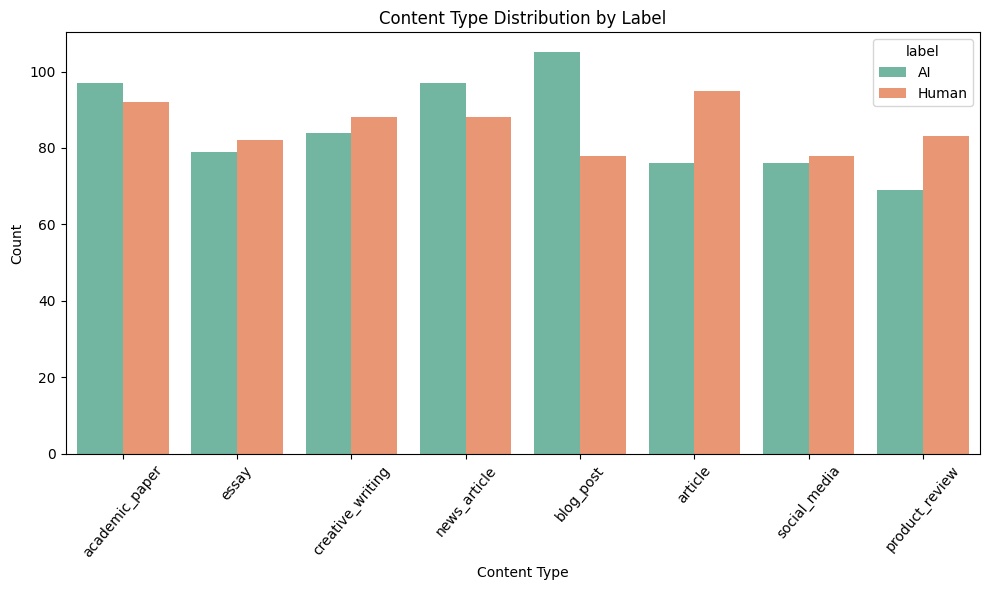

In [303]:
# Check if 'label' is numeric and convert for visualization
df['label'] = df['label'].map({0: 'Human', 1: 'AI'})

# Plot barplot of content_type with hue by label
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='content_type', hue='label', palette='Set2')
plt.title("Content Type Distribution by Label")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()


## 2.2 Target Variable Distribution

label
Human    684
AI       683
Name: count, dtype: int64


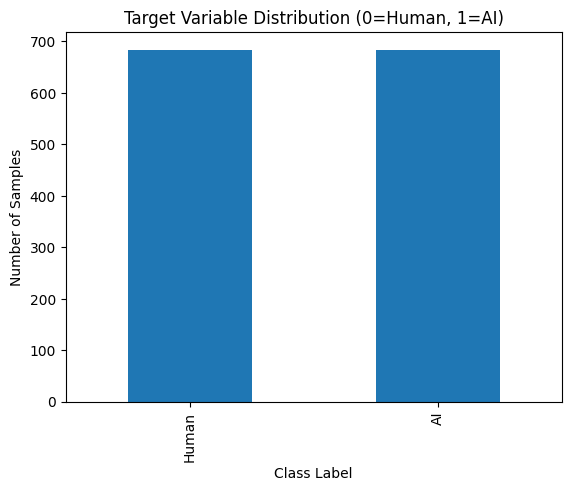

In [304]:
# Count the number of samples for each class
label_counts = df['label'].value_counts()

# Display counts
print(label_counts)

plt.figure()
label_counts.plot(kind='bar')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.title('Target Variable Distribution (0=Human, 1=AI)')
plt.show()

## 2.3 Univariate Analysis

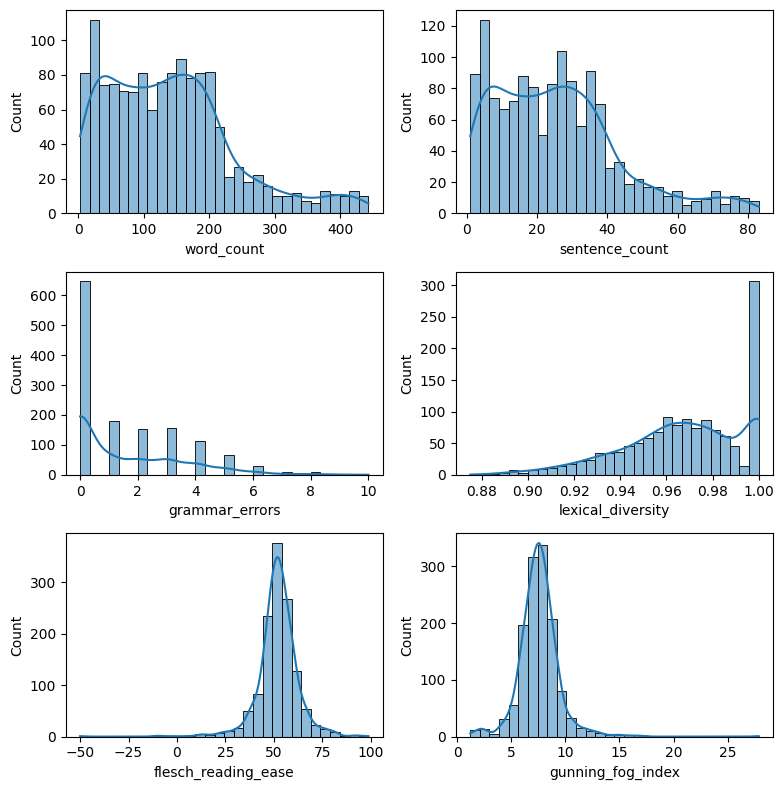

In [305]:
plt.figure(figsize=(8, 8))
def plotting(var,num):
    plt.subplot(3,2,num)
    sns.histplot(df[var], bins=30, kde = True)

plotting("word_count",1)
plotting("sentence_count",2)
plotting("grammar_errors",3)
plotting("lexical_diversity",4)
plotting("flesch_reading_ease",5)
plotting("gunning_fog_index", 6)

plt.tight_layout()

## 2.4 Bivariate Analysis (Feature vs Target)

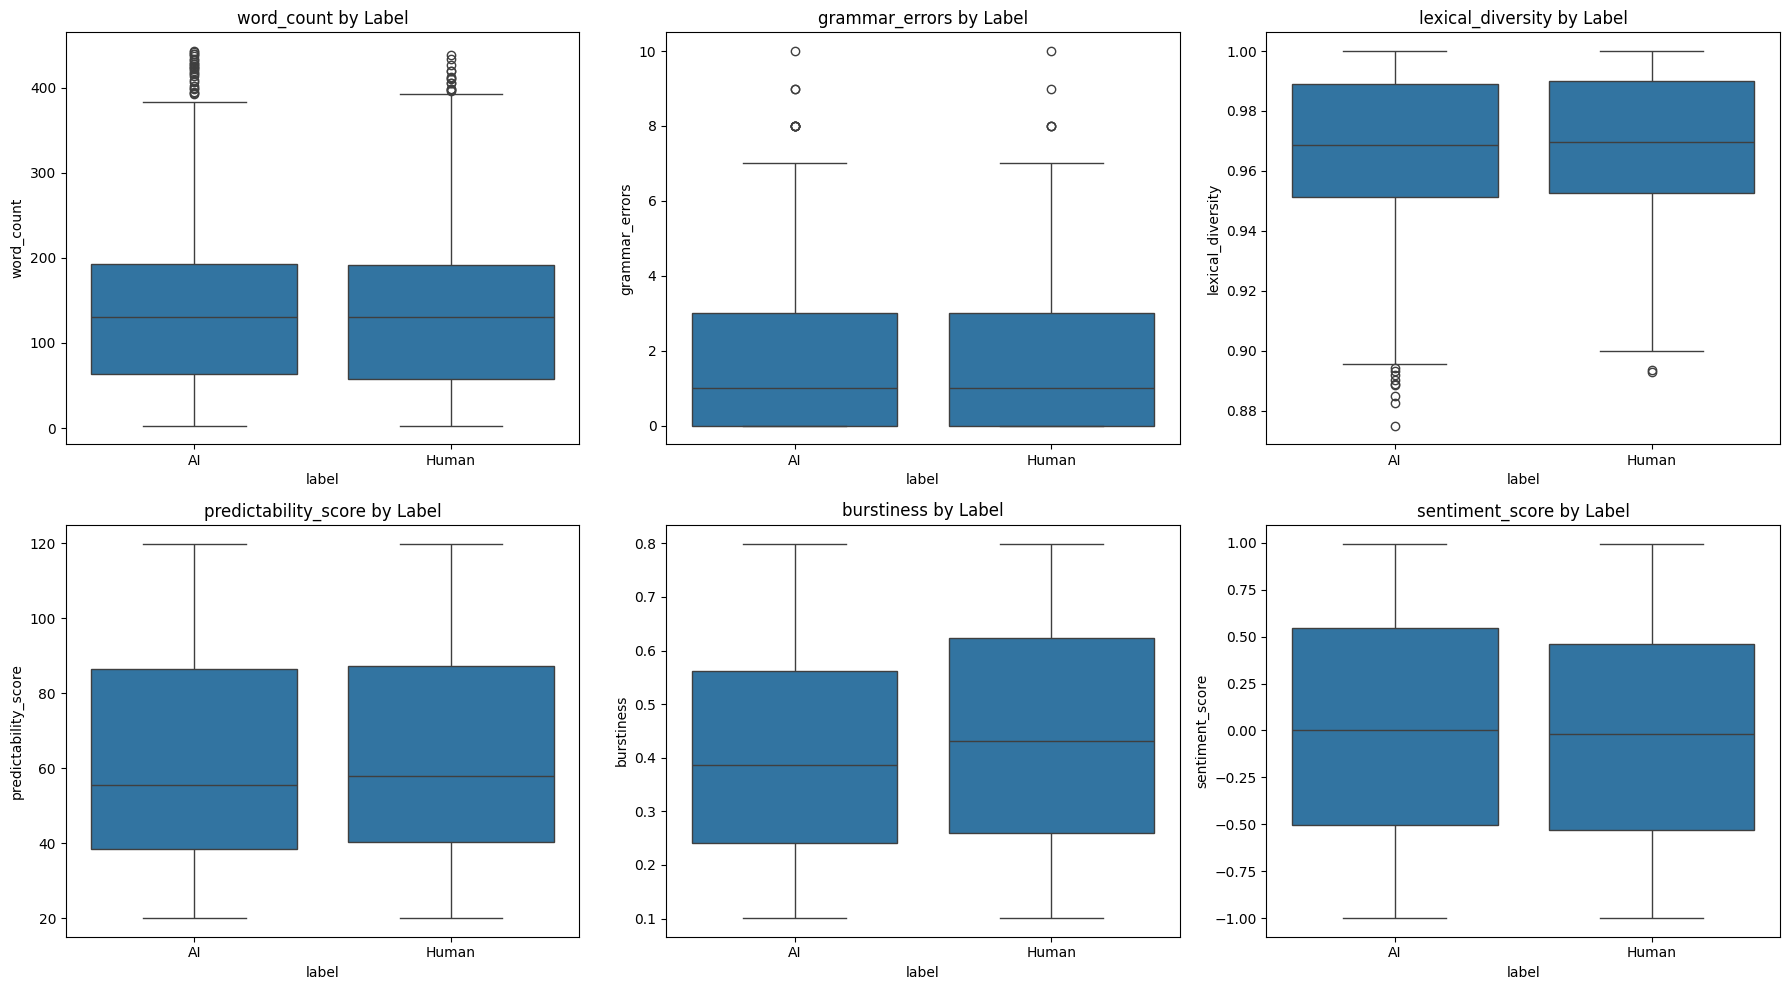

In [306]:
features_to_plot = ['word_count', 'grammar_errors', 'lexical_diversity', 'predictability_score', 'burstiness', 'sentiment_score']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(data=df, x='label', y=col, ax=axes[i])
    axes[i].set_title(f"{col} by Label")

plt.tight_layout()
plt.show()

## 2.4 Multivariate Analysis (Feature Relationships)

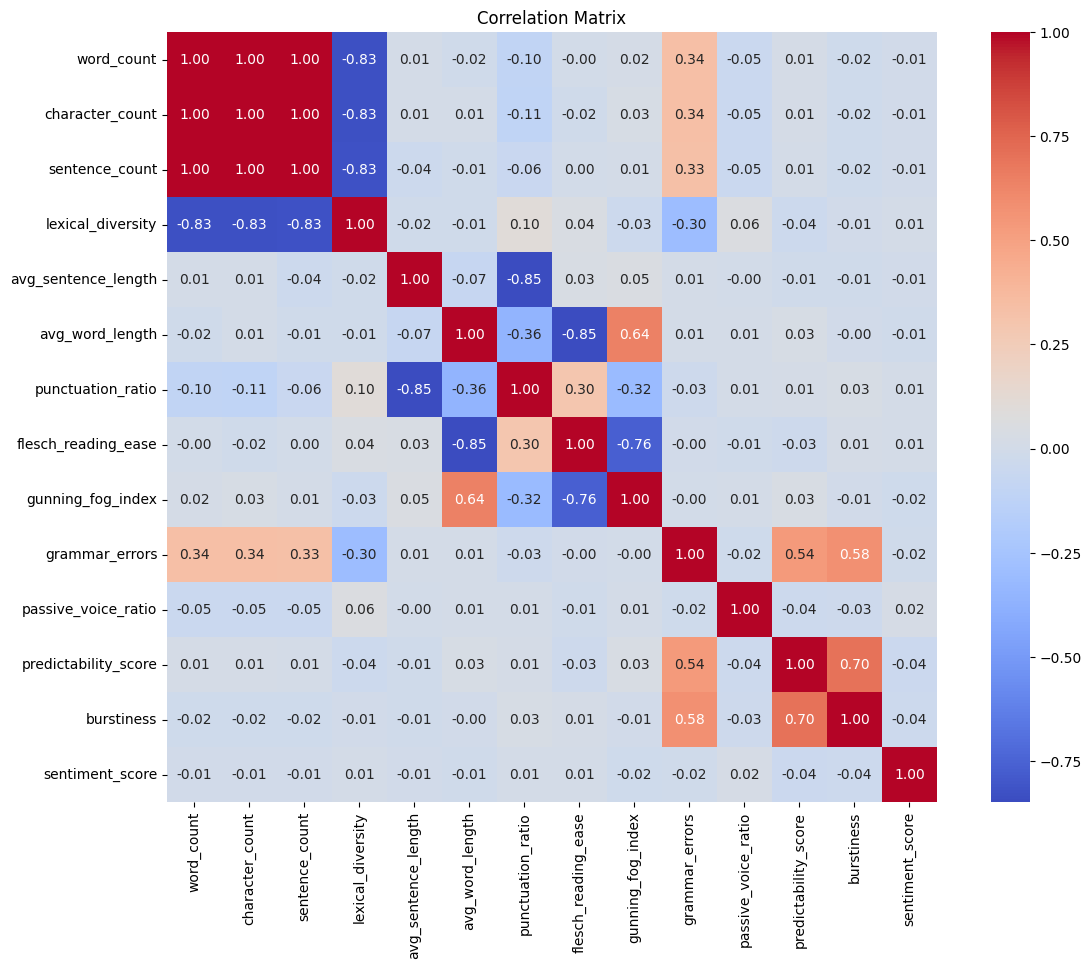

In [307]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()

# 3. Data Cleaning & Preprocessing

## 3.1 Check Missing Values

In [308]:
df.isnull().sum()

,0
text_content,0
content_type,0
word_count,0
character_count,0
sentence_count,0
lexical_diversity,0
avg_sentence_length,0
avg_word_length,0
punctuation_ratio,0
flesch_reading_ease,79


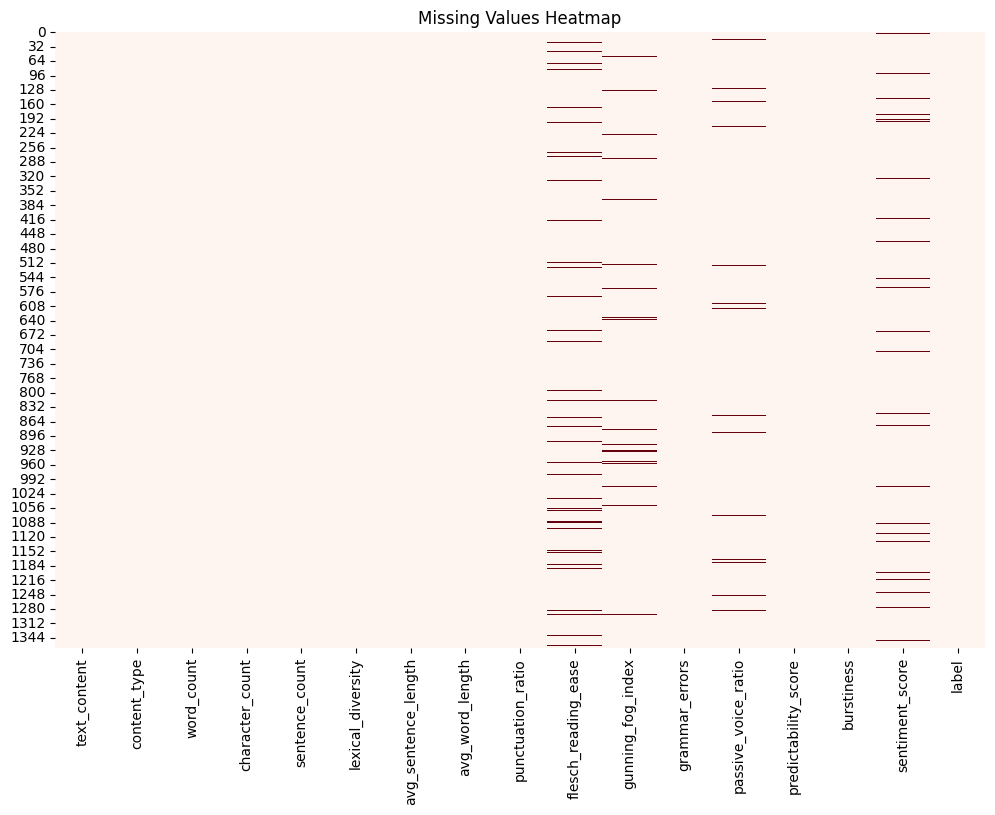

In [309]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='Reds')
plt.title("Missing Values Heatmap")
plt.show()

## 3.2 Handle Missing Values

In [310]:
# List of columns with missing values
missing_cols = [
    "flesch_reading_ease",
    "gunning_fog_index",
    "passive_voice_ratio",
    "sentiment_score"
]

# Fill missing values using median
for col in missing_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

# Verify that missing values are handled
df.isnull().sum()

,0
text_content,0
content_type,0
word_count,0
character_count,0
sentence_count,0
lexical_diversity,0
avg_sentence_length,0
avg_word_length,0
punctuation_ratio,0
flesch_reading_ease,0


Missing values were observed in readability and linguistic features such as Flesch Reading Ease, Gunning Fog Index, Passive Voice Ratio, and Sentiment Score. Since these are continuous numerical variables and the proportion of missing values was small, median imputation was applied to preserve dataset size and reduce the impact of outliers.

## Step 3.3: Check Duplicate Records

In [311]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

No duplicate records were found in the dataset, indicating that each instance represents a unique content sample.

## Step 3.4: Remove Unnecessary Columns (Features)

In [312]:
df.columns

Index(['text_content', 'content_type', 'word_count', 'character_count',
       'sentence_count', 'lexical_diversity', 'avg_sentence_length',
       'avg_word_length', 'punctuation_ratio', 'flesch_reading_ease',
       'gunning_fog_index', 'grammar_errors', 'passive_voice_ratio',
       'predictability_score', 'burstiness', 'sentiment_score', 'label'],
      dtype='object')

The raw text feature (text_content) was removed since the modeling pipeline relies on numerical and categorical features only, and no text vectorization techniques were applied. All remaining features represent engineered linguistic, readability, and stylistic metrics relevant for AI–human content classification.

In [313]:
# Drop raw text column (not used in numerical ML models)
df.drop(columns=["text_content"], inplace=True)
df.columns

Index(['content_type', 'word_count', 'character_count', 'sentence_count',
       'lexical_diversity', 'avg_sentence_length', 'avg_word_length',
       'punctuation_ratio', 'flesch_reading_ease', 'gunning_fog_index',
       'grammar_errors', 'passive_voice_ratio', 'predictability_score',
       'burstiness', 'sentiment_score', 'label'],
      dtype='object')

In [314]:
df['content_type'].value_counts()

,count
content_type,
academic_paper,189
news_article,185
blog_post,183
creative_writing,172
article,171
essay,161
social_media,154
product_review,152


## 3.5 Encode Categorical Features

In [315]:
# Converting lable feature to numeric
df['label'] = df['label'].map({'Human': 0, 'AI': 1})

In [316]:
# Identify categorical columns
df.select_dtypes(include=["object"]).columns

Index(['content_type'], dtype='object')

In [317]:
# One-Hot Encode the categorical feature
df = pd.get_dummies(df, columns=["content_type"], drop_first=True)

In [319]:
df.head()

,word_count,character_count,sentence_count,lexical_diversity,avg_sentence_length,avg_word_length,punctuation_ratio,flesch_reading_ease,gunning_fog_index,grammar_errors,...,burstiness,sentiment_score,label,content_type_article,content_type_blog_post,content_type_creative_writing,content_type_essay,content_type_news_article,content_type_product_review,content_type_social_media
0,288,1927,54,0.9514,5.33,5.69,0.0280,53.08,7.41,1,...,0.5531,0.2034,1,False,False,False,False,False,False,False
1,253,1719,45,0.9723,5.62,5.80,0.0262,50.32,8.10,6,...,0.5643,0.4854,1,False,False,False,True,False,False,False
2,420,2849,75,0.9071,5.60,5.79,0.0263,46.86,7.86,5,...,0.4979,-0.2369,1,False,False,False,False,False,False,False
3,196,1310,34,0.9592,5.76,5.69,0.0260,53.80,7.00,2,...,0.6241,-0.0062,1,False,False,True,False,False,False,False
4,160,1115,28,0.9688,5.71,5.97,0.0251,44.53,8.29,0,...,0.2894,-0.0062,1,False,False,False,False,True,False,False


In [320]:
# Convert boolean columns to integers
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [322]:
df.head()

,word_count,character_count,sentence_count,lexical_diversity,avg_sentence_length,avg_word_length,punctuation_ratio,flesch_reading_ease,gunning_fog_index,grammar_errors,...,burstiness,sentiment_score,label,content_type_article,content_type_blog_post,content_type_creative_writing,content_type_essay,content_type_news_article,content_type_product_review,content_type_social_media
0,288,1927,54,0.9514,5.33,5.69,0.0280,53.08,7.41,1,...,0.5531,0.2034,1,0,0,0,0,0,0,0
1,253,1719,45,0.9723,5.62,5.80,0.0262,50.32,8.10,6,...,0.5643,0.4854,1,0,0,0,1,0,0,0
2,420,2849,75,0.9071,5.60,5.79,0.0263,46.86,7.86,5,...,0.4979,-0.2369,1,0,0,0,0,0,0,0
3,196,1310,34,0.9592,5.76,5.69,0.0260,53.80,7.00,2,...,0.6241,-0.0062,1,0,0,1,0,0,0,0
4,160,1115,28,0.9688,5.71,5.97,0.0251,44.53,8.29,0,...,0.2894,-0.0062,1,0,0,0,0,1,0,0


The categorical feature content_type was converted into numerical form using one-hot encoding. This approach prevents the introduction of artificial ordinal relationships and ensures compatibility with machine learning algorithms such as Logistic Regression, SVM, and Random Forest.